In [1]:
# Imports

import os
import re
from dotenv import load_dotenv
from typing import TypedDict, Optional, Any, List

from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_community.vectorstores import Chroma

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_groq import ChatGroq

from sentence_transformers import CrossEncoder

from langgraph.graph import StateGraph, END

In [2]:
# environment

load_dotenv()

True

In [3]:
# embeddings

embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Load Constitution Vector DB

DB_PATH = r"C:\Users\user\Desktop\RAG Projects\Legal RAG 1\vector_database"

constitution_db = Chroma(
    persist_directory=DB_PATH,
    embedding_function=embeddings
)

C:\Users\user\AppData\Local\Temp\ipykernel_18688\3873132465.py:5: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  constitution_db = Chroma(


In [7]:
# llm

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [8]:
# Hierarchical Chunking Function

def hierarchical_split_documents(docs):

    splitter = RecursiveCharacterTextSplitter(
        chunk_size=500,
        chunk_overlap=100
    )

    chunks = splitter.split_documents(docs)

    paragraph_docs = []
    section_docs = []

    section_size = 5
    paragraph_size = 2

    for i, chunk in enumerate(chunks):

        chunk.metadata["level"] = "chunk"
        chunk.metadata["chunk_id"] = i
        paragraph_docs.append(chunk)

    # Paragraph summaries
    for i in range(0, len(chunks), paragraph_size):

        group = chunks[i:i+paragraph_size]
        text = "\n".join([c.page_content for c in group])

        summary = llm.invoke(
            f"Summarize this legal text in one sentence:\n{text}"
        ).content

        paragraph_docs.append(
            Document(
                page_content=summary,
                metadata={
                    "level": "paragraph_summary",
                    "start_chunk": i,
                    "end_chunk": i + paragraph_size
                }
            )
        )

    # Section summaries
    for i in range(0, len(chunks), section_size):

        group = chunks[i:i+section_size]
        text = "\n".join([c.page_content for c in group])

        summary = llm.invoke(
            f"Summarize this legal section briefly:\n{text}"
        ).content

        section_docs.append(
            Document(
                page_content=summary,
                metadata={
                    "level": "section_summary",
                    "start_chunk": i,
                    "end_chunk": i + section_size
                }
            )
        )

    return chunks + paragraph_docs + section_docs

In [9]:
# Load Uploaded Document
from langchain_community.document_loaders import PyPDFLoader

def load_uploaded_document(file_path):

    loader = PyPDFLoader(file_path)
    docs = loader.load()

    hierarchical_docs = hierarchical_split_documents(docs)

    vector_store = Chroma.from_documents(
        documents=hierarchical_docs,
        embedding=embeddings
    )

    return vector_store

In [10]:
# Legal Knowledge Retrieval

def retrieve_legal_docs(query, k=5):

    docs = constitution_db.similarity_search(query, k=k)

    return docs

In [11]:
# Graph State

class LegalState(TypedDict):

    question: str
    strategy: Optional[str]

    legal_docs: Optional[Any]
    document_docs: Optional[Any]

    answer: Optional[str]
    critique: Optional[str]

    graph_vector_store: Optional[Any]

In [12]:
# Cross Encoder Reranker

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
# Hierarchical Document Retrieval

def retrieve_document_docs(state: LegalState, k=10):

    vector_store = state.get("graph_vector_store")

    # If no uploaded document exists, skip document retrieval
    if vector_store is None:
        return []

    query = state["question"]

    # STEP 1: Retrieve section summaries
    section_docs = vector_store.similarity_search(
        query,
        k=5,
        filter={"level": "section_summary"}
    )

    chunks = []

    for section in section_docs:

        start = section.metadata.get("start_chunk", 0)
        end = section.metadata.get("end_chunk", 0)

        # STEP 2: retrieve chunks within that section
        results = vector_store.similarity_search(query, k=k)

        for r in results:

            if r.metadata.get("level") == "chunk":

                chunk_id = r.metadata.get("chunk_id", 0)

                if start <= chunk_id <= end:
                    chunks.append(r)

    return chunks

In [14]:
# API Validation

if not os.getenv("GROQ_API_KEY"):
    raise ValueError("GROQ_API_KEY not found")

In [37]:
# Strategist Agent

def strategist_agent(state: LegalState):

    question = state["question"]

    prompt = f"""
Decide the research strategy.

Question:
{question}

Options:
- legal
- document
- both

Return only one.
"""

    strategy = llm.invoke(prompt).content.strip()

    state["strategy"] = strategy

    return state

In [38]:
# Legal Research Agent

def legal_research_agent(state: LegalState):

    query = state["question"]

    docs = retrieve_legal_docs(query, k=8)

    state["legal_docs"] = docs

    return state

In [39]:
# Document Research Agent

def document_research_agent(state: LegalState):

    docs = retrieve_document_docs(state, k=12)

    state["document_docs"] = docs

    return state

In [40]:
# Answer Generator

def answer_agent(state: LegalState):

    legal_docs = state.get("legal_docs", [])
    doc_docs = state.get("document_docs", [])

    context = ""

    for d in legal_docs + doc_docs:
        context += d.page_content + "\n\n"

    prompt = f"""
Answer the question using the context.

Question:
{state["question"]}

Context:
{context}
"""

    answer = llm.invoke(prompt).content

    state["answer"] = answer

    return state

In [41]:
# Critic Agent

def critic_agent(state: LegalState):

    answer = state["answer"]

    critique = llm.invoke(
        f"Critique the following legal answer:\n{answer}"
    ).content

    state["critique"] = critique

    return state

In [42]:
# Router

def route_research(state: LegalState):

    strategy = state.get("strategy", "both")

    if strategy == "legal":
        return "legal_research"

    if strategy == "document":
        return "document_research"

    return "legal_research"

In [43]:
# Graph Workflow (Planner-style Hub-and-Spoke)

workflow = StateGraph(LegalState)

# Nodes
workflow.add_node("strategist", strategist_agent)
workflow.add_node("legal_research", legal_research_agent)
workflow.add_node("document_research", document_research_agent)
workflow.add_node("answer", answer_agent)
workflow.add_node("critic", critic_agent)


# Entry point
workflow.set_entry_point("strategist")


# Planner routing logic
def planner_router(state: LegalState):

    strategy = state.get("strategy", "both").lower()

    if strategy == "legal":
        return "legal_research"

    elif strategy == "document":
        return "document_research"

    elif strategy == "both":
        return "legal_research"

    else:
        return "answer"


# Strategist decides first action
workflow.add_conditional_edges(
    "strategist",
    planner_router
)


# Sequential retrieval planning
workflow.add_conditional_edges(
    "legal_research",
    lambda state: "document_research" if state.get("strategy") == "both" else "answer"
)


# Document research always proceeds to answer
workflow.add_edge("document_research", "answer")


# Answer then critique
workflow.add_edge("answer", "critic")


# Final state
workflow.add_edge("critic", END)


# Compile graph
legal_graph = workflow.compile()

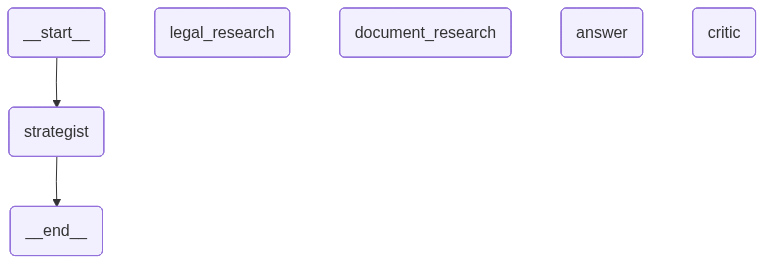

In [44]:
from IPython.display import Image, display

display(Image(legal_graph.get_graph().draw_mermaid_png()))

In [45]:
# Main RAG Function

def legal_agentic_rag(question, uploaded_file=None):

    vector_store = None

    if uploaded_file:
        vector_store = load_uploaded_document(uploaded_file)

    state = {
        "question": question,
        "graph_vector_store": vector_store
    }

    result = legal_graph.invoke(state)

    return result["answer"]

In [24]:
# Test: Central vs State law conflict

test_question = "If a state law conflicts with a central law in India, which prevails?"

expected_keywords = [
    "central law prevails",
    "union law prevails",
    "parliament law prevails",
    "article 254",
    "repugnancy"
]

response = legal_agentic_rag(test_question)

print("Question:", test_question)
print("\nLLM Answer:\n", response)


def evaluate_answer(answer, keywords):
    answer_lower = answer.lower()

    for k in keywords:
        if k in answer_lower:
            return True

    return False


is_correct = evaluate_answer(response, expected_keywords)

print("\nTest Result:", "PASS ✅" if is_correct else "FAIL ❌")

Question: If a state law conflicts with a central law in India, which prevails?

LLM Answer:
 In the context of India, if a state law conflicts with a central law, the central law prevails. This is based on the principles of the Indian Constitution, which establishes the supremacy of central laws over state laws in cases of conflict.

Test Result: PASS ✅


In [29]:
# File path of the uploaded case document
document_path = r"C:/Users/user/Desktop/RAG Projects/Legal RAG 1/data/Mrs_Vandana_Dhirani_vs_Mrs_Arti_Kirloskar_on_27_July_2023.PDF"

# Index the uploaded PDF using the hierarchical RAG loader
uploaded_vector_store = load_uploaded_document(document_path)


# Test questions designed to validate document-specific retrieval
document_tests = [

    (
        "Who is the plaintiff in this case?",
        "vandana dhirani",
        "Validate extraction of the primary party (plaintiff) from the case document."
    ),

]


print("\n--- EXECUTING DOCUMENT RETRIEVAL TESTS ---\n")


for i, (question, expected_key, explanation) in enumerate(document_tests):

    # Run the agentic RAG system using the uploaded document
    answer = legal_agentic_rag(
        question,
        uploaded_file=document_path
    )

    answer_clean = answer.strip().lower()

    # Initial evaluation check
    result_status = "PASS" if expected_key.lower() in answer_clean else "FAIL"


    # Flexible checks for alternative phrasing or synonyms
    if result_status == "FAIL":

        # Synonym handling
        if "dismiss" in answer_clean and expected_key.lower() == "dismissed":
            result_status = "PASS (Synonym Match)"

        elif "not entitled" in answer_clean and expected_key.lower() == "not found entitled":
            result_status = "PASS (Synonym Match)"

        # Partial match detection
        elif expected_key.lower() in answer_clean:
            result_status = "PASS (Partial Match)"

        # Named entity partial check
        elif "vandana" in answer_clean and "dhirani" in answer_clean:
            result_status = "PASS (Entity Match)"


    print(f"DOCUMENT TEST #{i+1}")
    print(f"Question: {question}")
    print(f"Model Answer: {answer.strip()}")
    print(f"Evaluation Result: {result_status} (Expected Key: {expected_key})")
    print(f"Test Purpose: {explanation}")
    print("-" * 60)

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kbn58qpqfjgstzyswyfty5g2` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99987, Requested 263. Please try again in 3m36s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

### Evaluation

In [30]:
evaluation_dataset = [

    {
        "question": "If a state law conflicts with a central law in India, which prevails?",
        "ground_truth": "Central law prevails under Article 254 of the Constitution of India."
    },

    {
        "question": "Which article guarantees equality before law?",
        "ground_truth": "Article 14 guarantees equality before law."
    },

]

In [46]:
def retrieval_recall(question, ground_truth, retrieved_docs):

    gt = ground_truth.lower()

    for doc in retrieved_docs:
        if gt[:20] in doc.page_content.lower():
            return 1

    return 0

In [47]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def answer_similarity(answer, ground_truth):

    emb1 = embeddings.embed_query(answer)
    emb2 = embeddings.embed_query(ground_truth)

    score = cosine_similarity([emb1], [emb2])[0][0]

    return score

In [48]:
def hallucination_check(question, answer):

    prompt = f"""
You are evaluating a legal QA system.

Question:
{question}

Answer:
{answer}

Check if the answer contains unsupported claims or hallucinations.

Return only:
PASS or FAIL
"""

    verdict = llm.invoke(prompt).content.strip()

    return verdict

In [53]:
def evaluate_rag_system(dataset):

    results = []

    for sample in dataset:

        question = sample["question"]
        ground_truth = sample["ground_truth"]

        print("\nEvaluating question:", question)

        # Run full RAG graph
        state = {
            "question": question,
            "graph_vector_store": None
        }

        result = legal_graph.invoke(state)

        answer = result.get("answer", "")

        # Collect retrieved docs used by the graph
        retrieved_docs = []

        if result.get("legal_docs"):
            retrieved_docs.extend(result["legal_docs"])

        if result.get("document_docs"):
            retrieved_docs.extend(result["document_docs"])

        # Metrics
        recall = retrieval_recall(question, ground_truth, retrieved_docs)
        similarity = answer_similarity(answer, ground_truth)
        hallucination = hallucination_check(question, answer)

        results.append({
            "question": question,
            "recall": recall,
            "similarity": similarity,
            "hallucination": hallucination
        })

        print("Answer:", answer)
        print("Retrieved Docs:", len(retrieved_docs))
        print("Retrieval Recall:", recall)
        print("Answer Similarity:", round(similarity, 3))
        print("Hallucination Check:", hallucination)
        print("-" * 60)

    return results

In [50]:
evaluation_results = evaluate_rag_system(evaluation_dataset)


Evaluating question: If a state law conflicts with a central law in India, which prevails?
Answer: In the context of India, if a state law conflicts with a central law, the central law prevails. This is based on the principles of the Indian Constitution, which establishes the supremacy of central laws over state laws in cases of conflict.
Retrieval Recall: 0
Answer Similarity: 0.724
Hallucination Check: PASS
------------------------------------------------------------

Evaluating question: Which article guarantees equality before law?
Answer: You haven't provided the context. Please provide the context so I can answer your question accurately.
Retrieval Recall: 0
Answer Similarity: 0.468
Hallucination Check: FAIL
------------------------------------------------------------


In [51]:
def summarize_results(results):

    recall_scores = [r["recall"] for r in results]
    similarity_scores = [r["similarity"] for r in results]

    hallucinations = [1 if r["hallucination"] == "PASS" else 0 for r in results]

    print("\n--- RAG PERFORMANCE SUMMARY ---\n")

    print("Retrieval Recall:", sum(recall_scores)/len(recall_scores))
    print("Avg Answer Similarity:", sum(similarity_scores)/len(similarity_scores))
    print("Grounded Answer Rate:", sum(hallucinations)/len(hallucinations))

In [52]:
summarize_results(evaluation_results)


--- RAG PERFORMANCE SUMMARY ---

Retrieval Recall: 0.0
Avg Answer Similarity: 0.5958908993697052
Grounded Answer Rate: 0.5
